# Notebook 03 — Prediction Models (Stage 2)
Trains and compares regression models to predict monthly waste generation per district, then generates a single-step next-month forecast using the winning model.

**Input:** `features.parquet`
**Output:** `models/best_model_rf.pkl`, `next_month_forecast.parquet`, `model_comparison_results.csv`

In [1]:
# Setup: imports, paths, and load Stage 1 feature-engineered data.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib

%matplotlib inline

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

features = pd.read_parquet(PROCESSED / "features.parquet")
print(features.shape)

(24411, 27)


In [2]:
# Time-based train/test split. Deliberately NOT a random split — random splitting would leak
# future information into training for time-series data. Train on data before 2024, test on after.
split_date = "2024-01-01"
train = features[features["date"] < split_date]
test = features[features["date"] >= split_date]

print("Train rows:", len(train), "| Test rows:", len(test))
print("Train range:", train["date"].min(), "to", train["date"].max())
print("Test range:", test["date"].min(), "to", test["date"].max())

Train rows: 22641 | Test rows: 1770
Train range: 1991-05-01 00:00:00 to 2023-12-01 00:00:00
Test range: 2024-01-01 00:00:00 to 2026-06-01 00:00:00


In [3]:
# Define feature columns and target, split into X/y for train and test.
feature_cols = [
    "year", "month_num", "quarter", "is_summer", "is_winter",
    "total_tons_lag1", "total_tons_lag12",
    "rolling_3m_avg", "rolling_12m_avg",
    "area_sqm", "centroid_lat", "centroid_lon"
]
target_col = "total_tons"

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (22641, 12) | X_test: (1770, 12)


In [4]:
# Train and evaluate 4 candidate approaches in one pass: a naive baseline (predict = last
# month's value) plus Linear Regression, Random Forest, and XGBoost. Metrics: RMSE, MAE,
# MAPE, R² — MAPE is included since it's easiest to communicate in a report ("~X% error").
naive_preds = X_test["total_tons_lag1"]

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42),
}

predictions = {"Naive": naive_preds}
results_rows = []

for name, preds in [("Naive", naive_preds)]:
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    mape = (abs((y_test - preds) / y_test)).mean() * 100
    r2 = r2_score(y_test, preds)
    results_rows.append({"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2})

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    mape = (abs((y_test - preds) / y_test)).mean() * 100
    r2 = r2_score(y_test, preds)
    results_rows.append({"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2})

results = pd.DataFrame(results_rows).sort_values("RMSE").reset_index(drop=True)
results

,Model,RMSE,MAE,MAPE (%),R²
0,Random Forest,256.507402,185.118498,3.564306,0.980164
1,XGBoost,276.789597,197.520430,3.862459,0.976903
2,Linear Regression,314.397957,232.897585,4.545353,0.970200
3,Naive,505.328831,372.214350,7.299852,0.923015


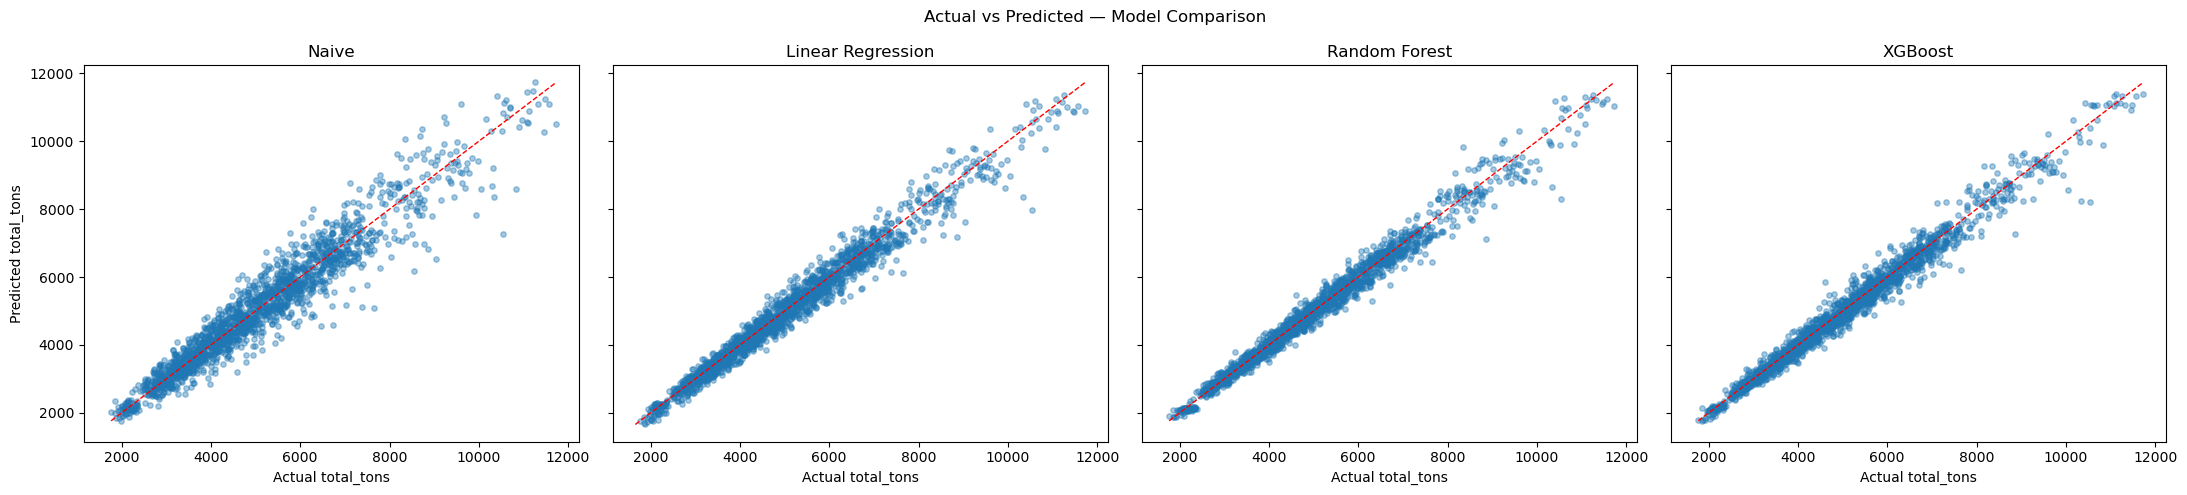

In [5]:
# Actual vs Predicted scatter plots for all 4 approaches, side by side. Points hugging the
# diagonal = accurate predictions. This is the key visual evidence for model selection.
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.4, s=15)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual total_tons")

axes[0].set_ylabel("Predicted total_tons")
plt.suptitle("Actual vs Predicted — Model Comparison")
plt.tight_layout()
plt.savefig(PROCESSED / "actual_vs_predicted_comparison.png", dpi=150)
plt.show()

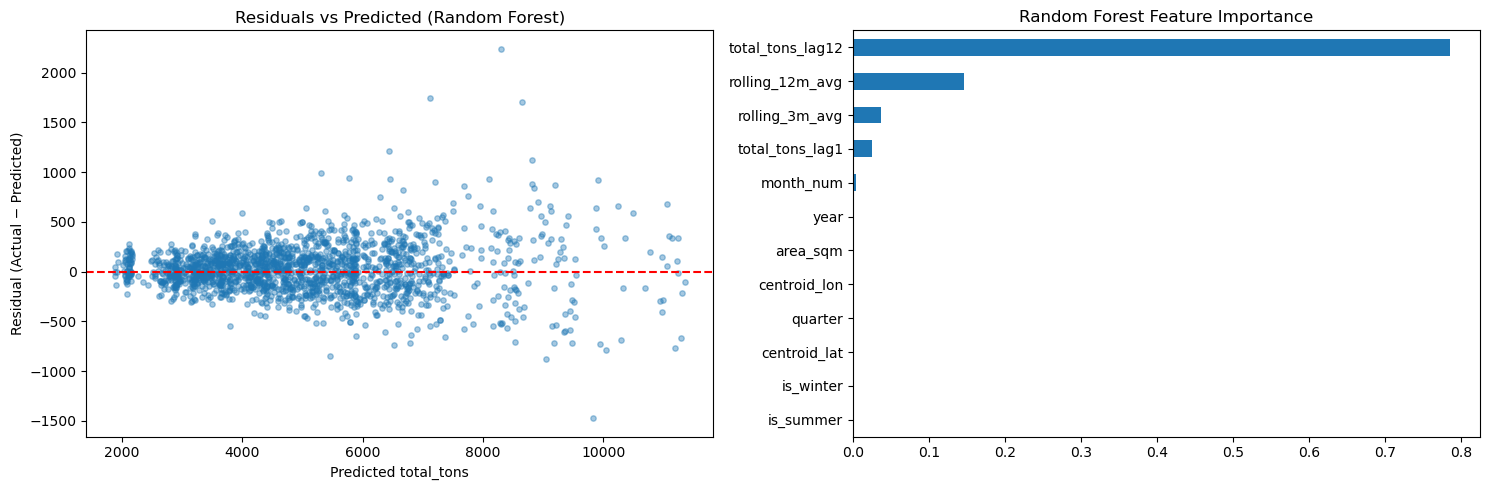

Train R²: 0.981 | Test R²: 0.980  (close values confirm no overfitting)


In [6]:
# Winner: Random Forest (best RMSE/MAE/MAPE/R² in the comparison table above).
# Diagnostics on the winning model: residual pattern, feature importance, and an
# overfitting check (train R² vs test R² — should be close; a big gap would indicate overfitting).
rf = models["Random Forest"]
rf_preds = predictions["Random Forest"]
rf_r2 = results.loc[results["Model"] == "Random Forest", "R²"].values[0]

residuals = y_test - rf_preds
train_r2 = r2_score(y_train, rf.predict(X_train))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(rf_preds, residuals, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted total_tons")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted (Random Forest)")

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=axes[1])
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.savefig(PROCESSED / "rf_diagnostics.png", dpi=150)
plt.show()

print(f"Train R²: {train_r2:.3f} | Test R²: {rf_r2:.3f}  (close values confirm no overfitting)")

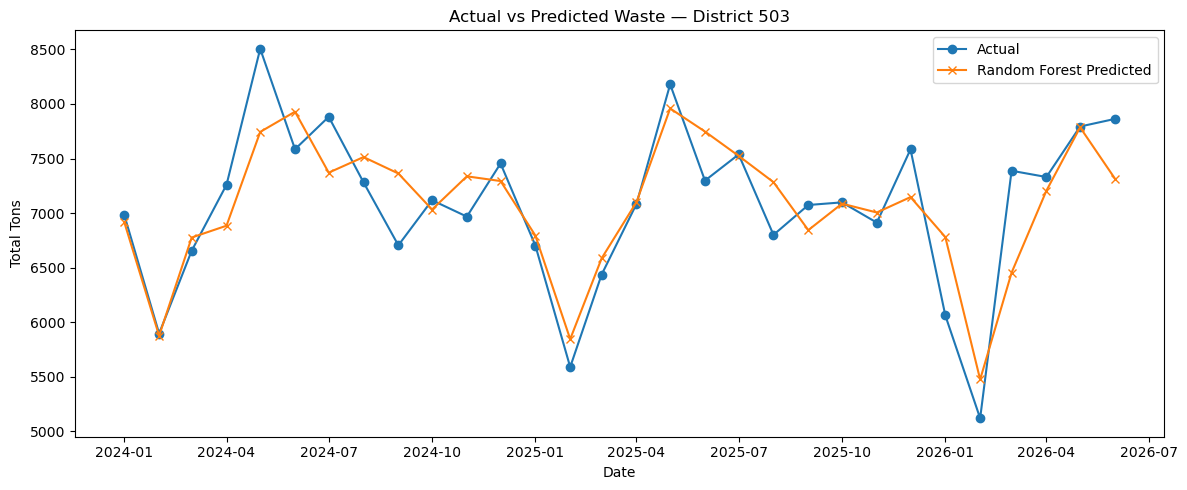

In [13]:
# Sanity check: actual vs predicted waste over time for one sample district — confirms the
# model tracks real month-to-month patterns, not just aggregate error metrics.
sample_district = test["BoroCd"].unique()[58]
mask = test["BoroCd"] == sample_district

plt.figure(figsize=(12, 5))
plt.plot(test.loc[mask, "date"], y_test[mask], label="Actual", marker="o")
plt.plot(test.loc[mask, "date"], rf_preds[mask], label="Random Forest Predicted", marker="x")
plt.title(f"Actual vs Predicted Waste — District {sample_district}")
plt.xlabel("Date")
plt.ylabel("Total Tons")
plt.legend()
plt.tight_layout()
plt.savefig(PROCESSED / f"timeseries_district_{sample_district}.png", dpi=150)
plt.show()

In [8]:
# Generate a genuine forward forecast: predict next month's waste for every district using
# the trained Random Forest model. Builds each district's next-month feature row from its
# most recent 12 months of actual history (lag/rolling features computed fresh, not reused
# from training data).
next_date = features["date"].max() + pd.DateOffset(months=1)
print("Forecasting for:", next_date.date())

last_known = (
    features.sort_values(["BoroCd", "date"])
    .groupby("BoroCd")
    .tail(12)
    .copy()
)

def make_future_row(history_df, boro_cd, next_date):
    hist = history_df[history_df["BoroCd"] == boro_cd].sort_values("date")
    row = {
        "BoroCd": boro_cd, "date": next_date,
        "year": next_date.year, "month_num": next_date.month,
        "quarter": (next_date.month - 1) // 3 + 1,
        "is_summer": int(next_date.month in [6, 7, 8]),
        "is_winter": int(next_date.month in [12, 1, 2]),
        "total_tons_lag1": hist["total_tons"].iloc[-1],
        "total_tons_lag12": hist["total_tons"].iloc[-12] if len(hist) >= 12 else hist["total_tons"].iloc[0],
        "rolling_3m_avg": hist["total_tons"].tail(3).mean(),
        "rolling_12m_avg": hist["total_tons"].tail(12).mean(),
        "area_sqm": hist["area_sqm"].iloc[-1],
        "centroid_lat": hist["centroid_lat"].iloc[-1],
        "centroid_lon": hist["centroid_lon"].iloc[-1],
    }
    return row

future_rows = [make_future_row(last_known, b, next_date) for b in last_known["BoroCd"].unique()]
next_month_forecast = pd.DataFrame(future_rows)
next_month_forecast["predicted_tons"] = rf.predict(next_month_forecast[feature_cols])

print(next_month_forecast.shape)
next_month_forecast[["BoroCd", "date", "predicted_tons"]].sort_values("predicted_tons", ascending=False).head(10)

Forecasting for: 2026-07-01
(59, 15)


,BoroCd,date,predicted_tons
48,407,2026-07-01,11154.379155
34,311,2026-07-01,9464.657567
53,412,2026-07-01,9389.116680
13,202,2026-07-01,8607.867505
58,503,2026-07-01,7393.248495
54,413,2026-07-01,7321.458157
56,501,2026-07-01,7282.282911
35,312,2026-07-01,7030.534565
7,108,2026-07-01,6996.550981
41,318,2026-07-01,6993.185055


In [9]:
# Forecast sanity check: compare each district's next-month forecast against its own recent
# 6-month average, to catch any wildly unrealistic predictions before using them downstream.
recent_avg = features.sort_values("date").groupby("BoroCd")["total_tons"].apply(lambda x: x.tail(6).mean())
check = next_month_forecast.merge(recent_avg.rename("recent_6m_avg"), on="BoroCd")
check["pct_diff"] = ((check["predicted_tons"] - check["recent_6m_avg"]) / check["recent_6m_avg"]) * 100

print("Largest deviations from recent 6-month average (top 10 by absolute %):")
check[["BoroCd", "predicted_tons", "recent_6m_avg", "pct_diff"]].sort_values("pct_diff", key=abs, ascending=False).head(10)

Largest deviations from recent 6-month average (top 10 by absolute %):


,BoroCd,predicted_tons,recent_6m_avg,pct_diff
35,312,7030.534565,8512.100000,-17.405404
54,413,7321.458157,6329.200000,15.677466
24,301,6400.669722,7511.433333,-14.787639
51,410,5104.252963,4530.616667,12.661329
55,414,4641.904353,4161.166667,11.552954
53,412,9389.116680,8430.800000,11.366853
52,411,4132.460339,3718.116667,11.143913
21,210,3558.871070,3208.216667,10.929885
23,212,5213.265153,4721.616667,10.412715
49,408,4917.063746,4521.216667,8.755322


In [10]:
# Save final Stage 2 outputs: the trained model, the next-month forecast, and the model
# comparison table. Re-running this notebook overwrites these same filenames.
joblib.dump(rf, MODELS_DIR / "best_model_rf.pkl")
next_month_forecast.to_parquet(PROCESSED / "next_month_forecast.parquet", index=False)
results.to_csv(PROCESSED / "model_comparison_results.csv", index=False)

print("Saved:")
print(" -", MODELS_DIR / "best_model_rf.pkl")
print(" -", PROCESSED / "next_month_forecast.parquet")
print(" -", PROCESSED / "model_comparison_results.csv")
print(f"\nNotebook 03 complete. Winning model: Random Forest (Test R²={rf_r2:.3f}).")
print(f"Forecasted next month ({next_date.date()}) for {next_month_forecast['BoroCd'].nunique()} districts.")

Saved:
 - C:\Users\pande\OneDrive\Documents\Waste management grid\models\best_model_rf.pkl
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\next_month_forecast.parquet
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\model_comparison_results.csv

Notebook 03 complete. Winning model: Random Forest (Test R²=0.980).
Forecasted next month (2026-07-01) for 59 districts.
